# Draw & Guess：605 张卡牌加权草图适配器

这份 notebook 记录本次**实际训练**的数据、图例、DINOv2 特征缓存、残差 MLP 适配器、按卡牌身份划分的五折交叉验证、融合策略比较、配对条件概率与 ONNX 导出。

- 605 张游戏卡牌，每张 4 张训练草图，共 2,420 张；
- 训练草图由 Codex 与 Stroke2Sketch 生成；
- 每张卡牌的 Codex 数据权重合计 `0.5`，Stroke2Sketch 数据权重合计 `0.5`；
- 鸡煲基线：`50% 手工特征 + 50% 原始 DINOv2`；
- 新模型：`30% 手工特征 + 70% 适配后 DINOv2`；
- 所有折外指标都保证测试卡牌没有参与该折训练。

下方保存的数字来自 2026-07-28 对本目录实际数据和模型产物的完整运行，不是演示数字。游戏资源和生成训练图只保存在本地，不应提交到公开仓库。

## 0. 环境与路径

Python 3.11+。第一次建立特征缓存时，`timm` 会下载 `vit_small_patch14_dinov2.lvd142m`。普通查看、数据审计和读取已保存结果不需要重新下载或训练。

In [ ]:
# 只在当前 notebook 环境缺少依赖时运行一次。
%pip install numpy pillow torch torchvision timm onnx onnxruntime


In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
from collections import Counter
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw, ImageOps

SEED = 222
MODEL_NAME = "vit_small_patch14_dinov2.lvd142m"
INPUT_SIZE = 224
EMBEDDING_SIZE = 384
FOLDS = 5

working_directory = Path.cwd().resolve()
default_dataset = (
    working_directory
    if (working_directory / "manifest.json").is_file()
    else Path("path/to/stroke2sketch-605-dataset")
)
DATASET_ROOT = Path(
    os.environ.get("DRAW_GUESS_DATASET_ROOT", str(default_dataset))
).expanduser().resolve()
MANIFEST_PATH = DATASET_ROOT / "manifest.json"
TRAINING_ROOT = DATASET_ROOT / "training" / "weighted-adapter-v2"
REPORT_PATH = TRAINING_ROOT / "comparison-report.json"
TRAIN_SCRIPT = DATASET_ROOT / "scripts" / "train_and_compare_adapter.py"
RUN_FULL_TRAINING = False

print("dataset:", DATASET_ROOT)
print("manifest:", MANIFEST_PATH.is_file())
print("recorded report:", REPORT_PATH.is_file())
print("RUN_FULL_TRAINING =", RUN_FULL_TRAINING)


dataset: <DRAW_GUESS_DATASET_ROOT>
manifest: True
recorded report: True
RUN_FULL_TRAINING = False


## 1. 实际训练流水线

```text
游戏卡图 ─ Codex + Stroke2Sketch 训练草图 ─ 冻结 DINOv2 ─ 残差 MLP ─┐
游戏卡图 ─────────────────────────────── DINO 图库原型 ────────────┼─ z-score 融合 ─ 猜牌
游戏卡图/草图 ─────────────────────────── 手工特征分支 ───────────┘
```

DINOv2 本身保持冻结。训练的只是约 39.5 万参数的小型残差适配器，因此它学习的是“玩家草图的 DINO 表示应该怎样移动”，而不是从头学习整套视觉模型。

## 2. 二十张真实游戏卡牌图例

下面四页由实际游戏卡图和本次真实训练数据组成。每一行都标注了来源卡牌，并展示原图以及由 Codex 和 Stroke2Sketch 生成的训练草图。

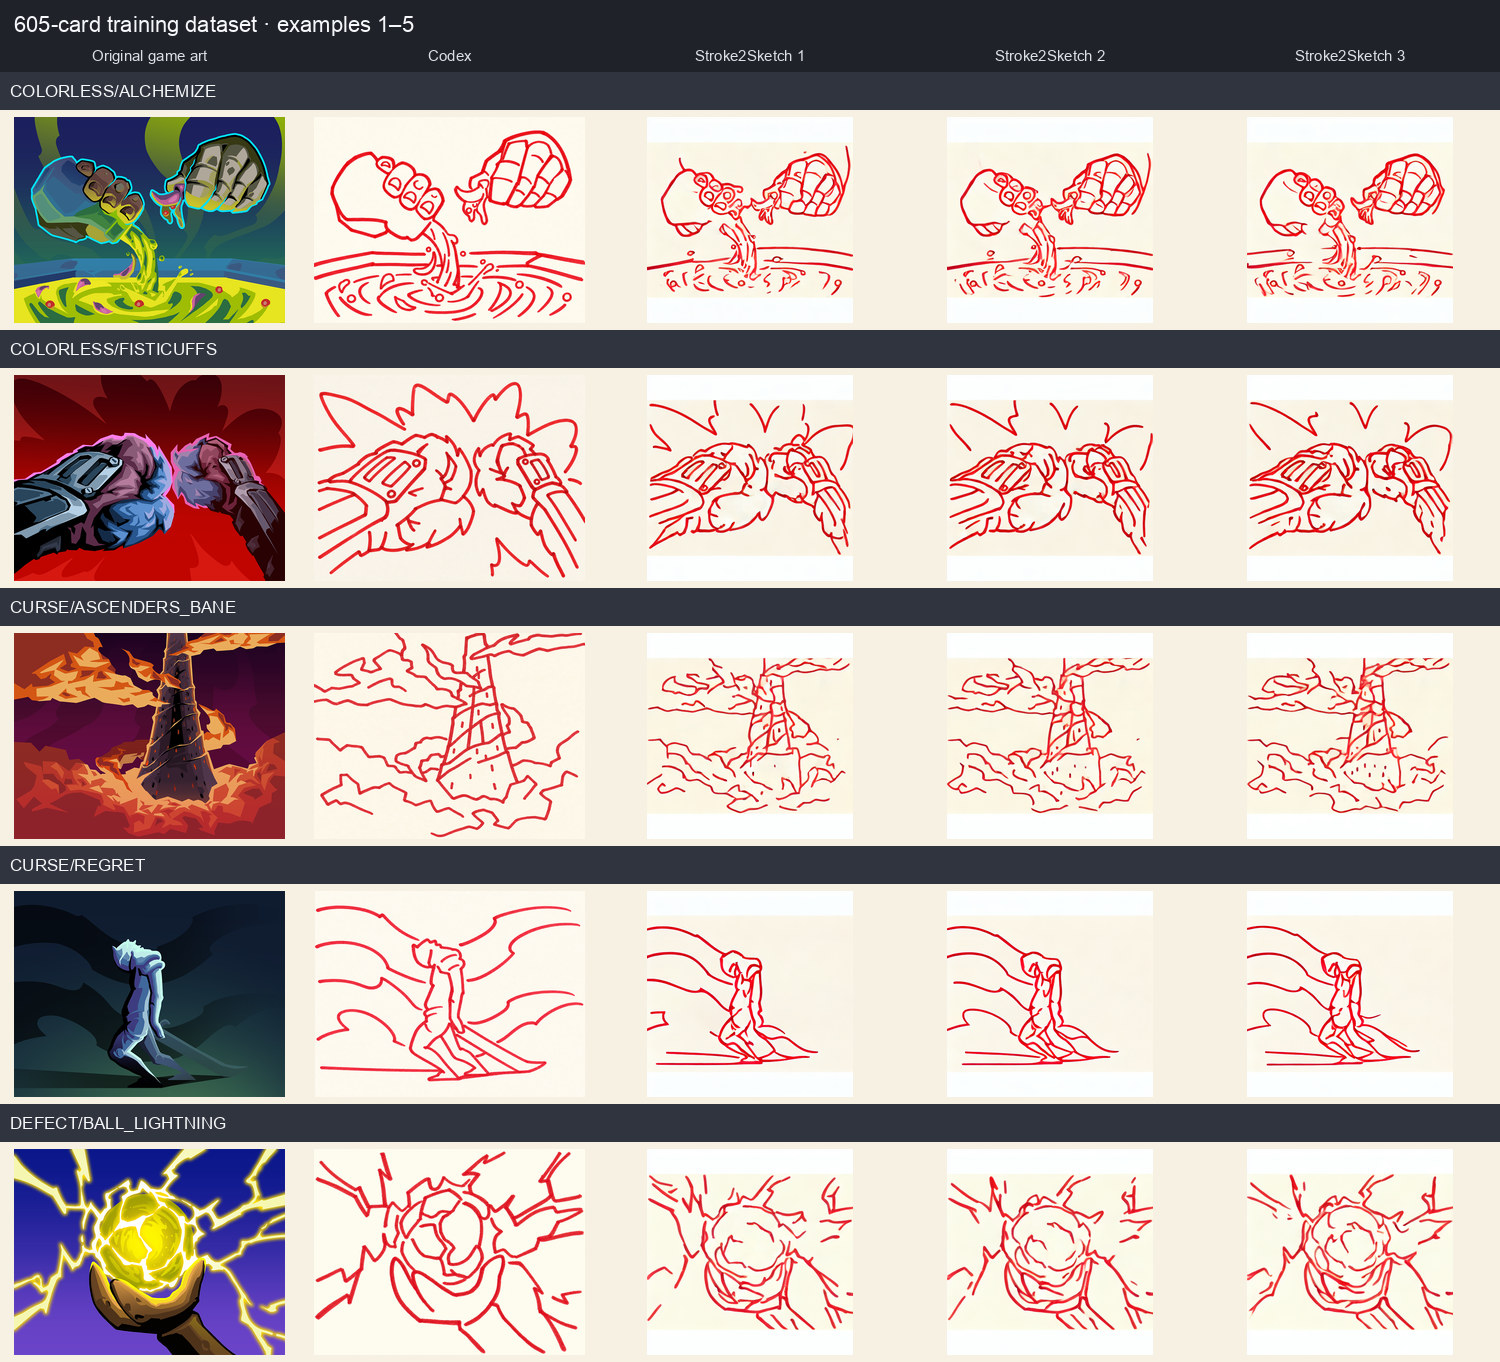

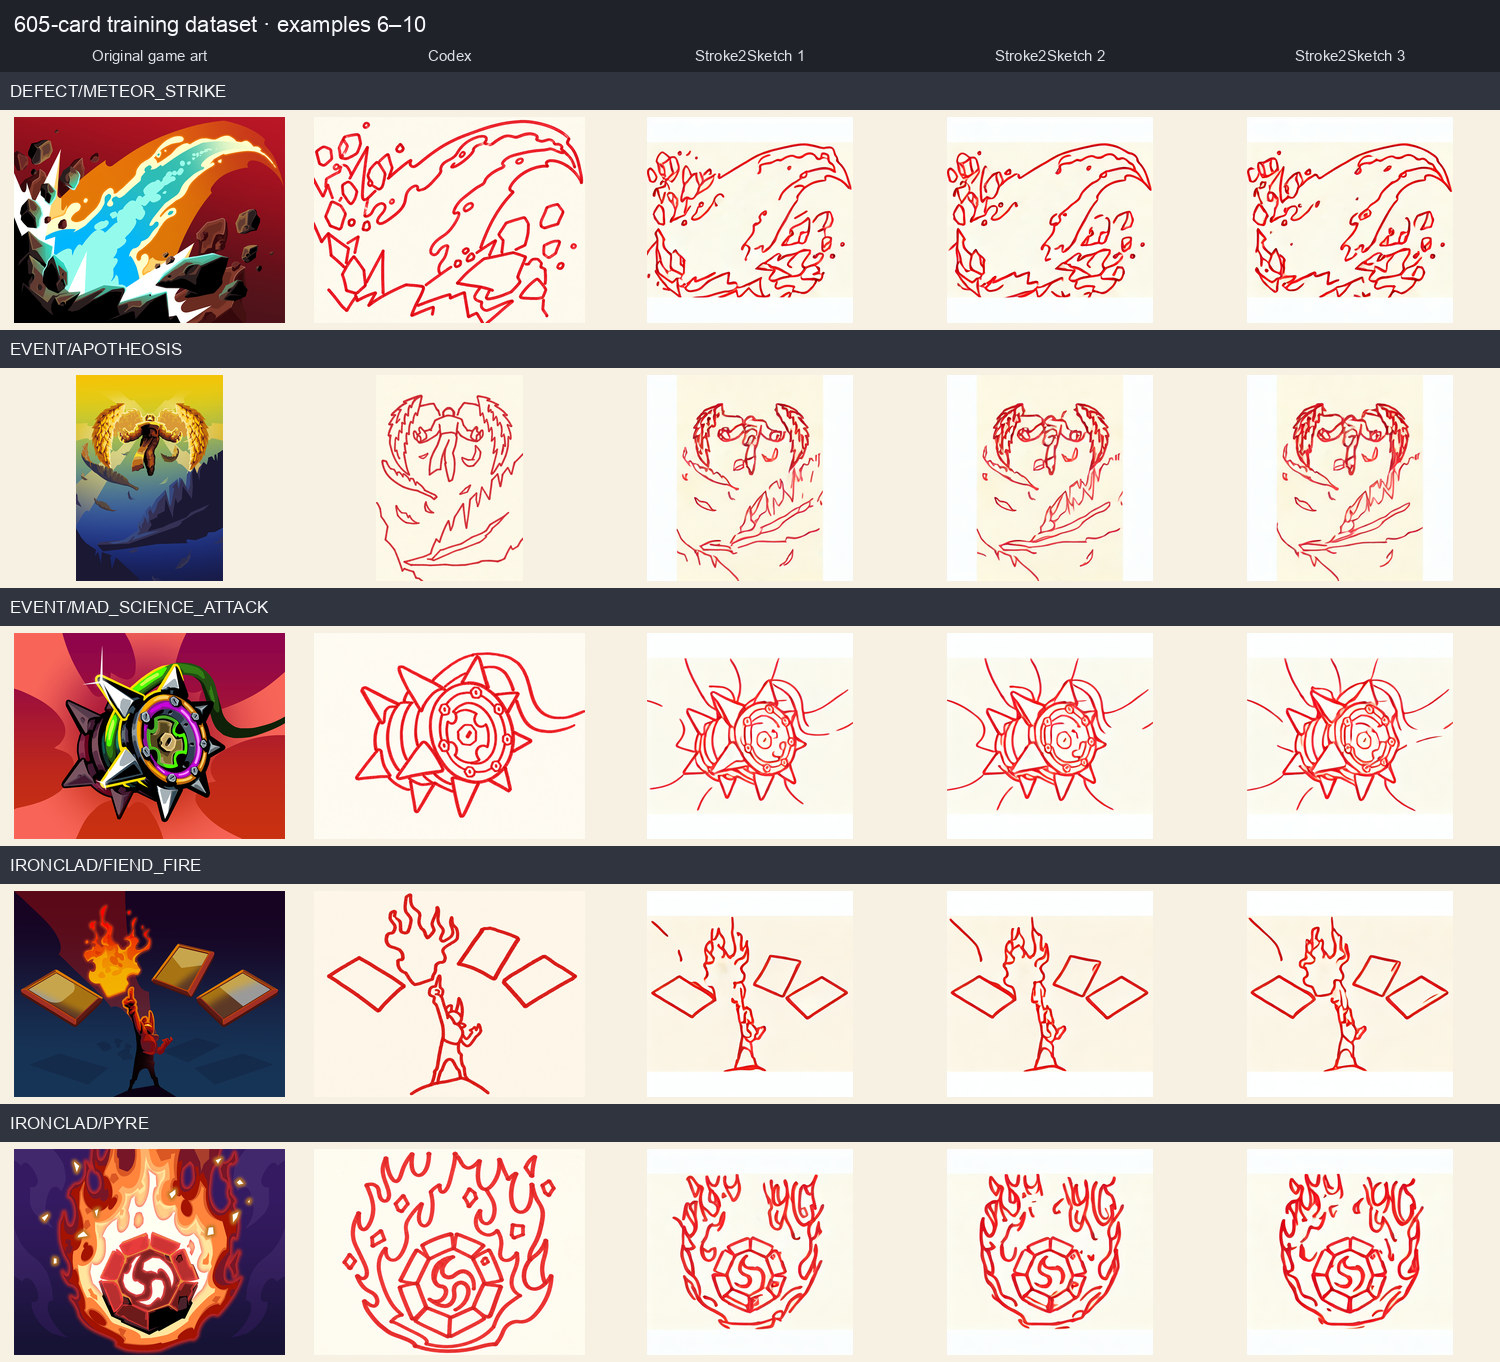

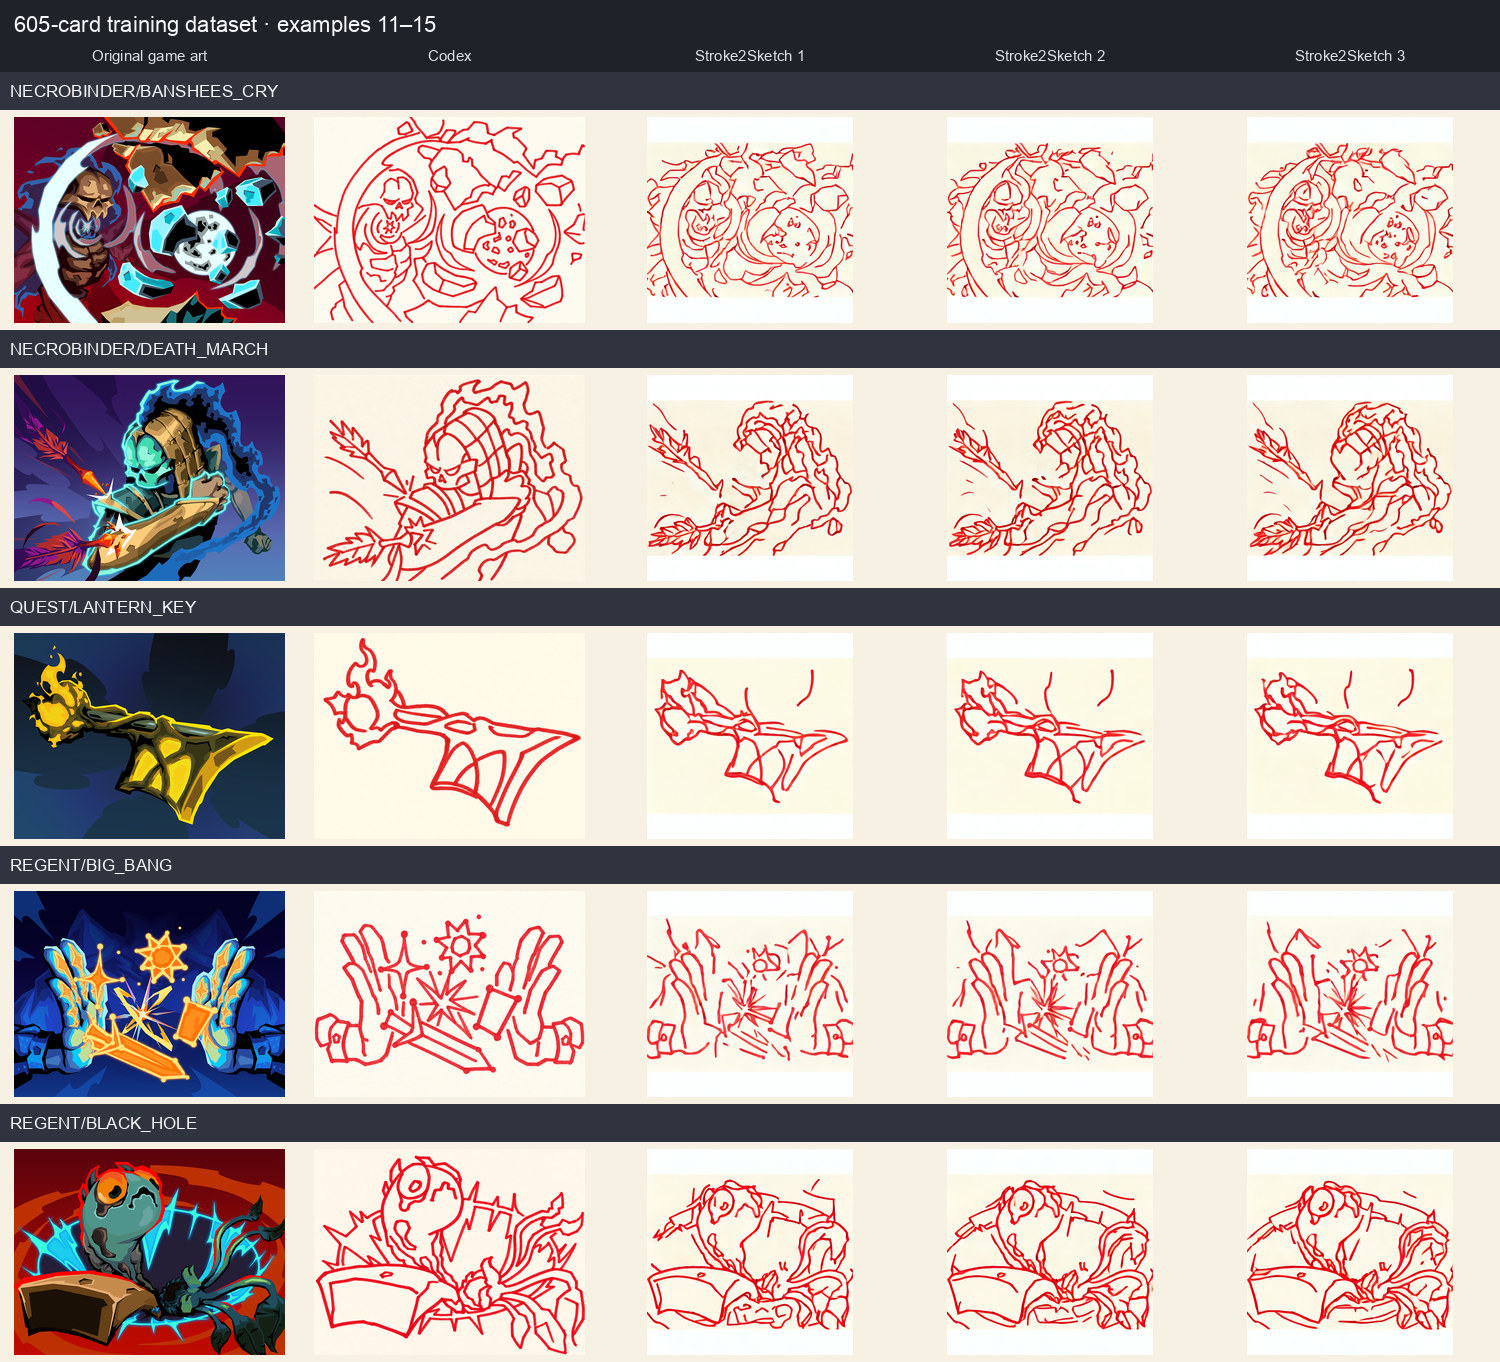

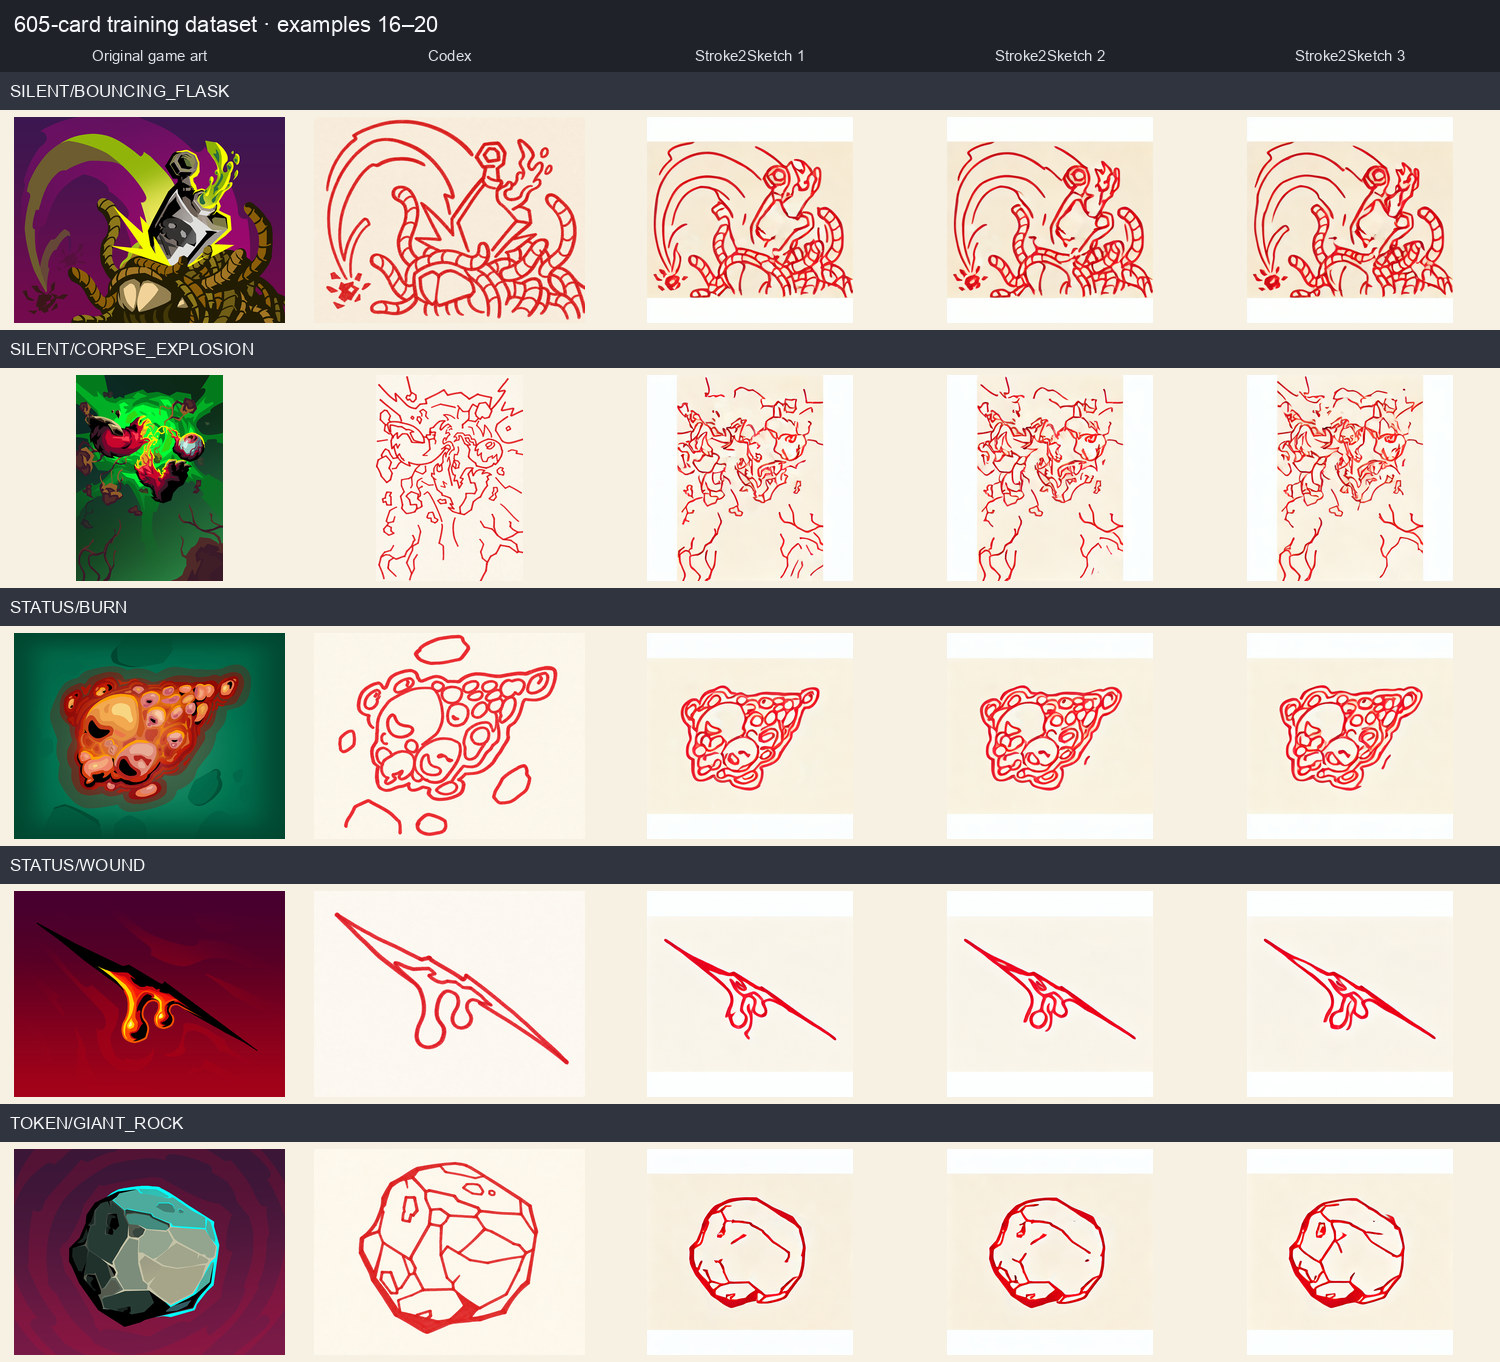

In [2]:
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
cards = manifest["cards"]
samples = [sample for card in cards for sample in card["generated"]]
source_counts = {
    "Codex": sum(
        Path(sample["relative_path"]).name == "codex.png"
        for sample in samples
    ),
    "Stroke2Sketch": sum(
        Path(sample["relative_path"]).name.startswith("stroke2sketch_")
        for sample in samples
    ),
}
status_counts = Counter(sample["status"] for sample in samples)
files_present = sum(
    (DATASET_ROOT / sample["relative_path"]).is_file()
    for sample in samples
)
card_weights = [
    sum(float(sample["weight"]) for sample in card["generated"])
    for card in cards
]

assert len(cards) == 605
assert len(samples) == 2420
assert files_present == 2420
assert all(math.isclose(weight, 1.0, abs_tol=1e-8) for weight in card_weights)
for card in cards:
    assert (DATASET_ROOT / card["local_original_path"]).is_file()
    for sample in card["generated"]:
        assert (DATASET_ROOT / sample["relative_path"]).is_file()

print({
    "cards": len(cards),
    "sketches": len(samples),
    "files_present": files_present,
    "per_source": source_counts,
    "manifest_status": dict(status_counts),
    "per_card_weight": card_weights[0],
})


{'cards': 605, 'sketches': 2420, 'files_present': 2420, 'per_source': {'Codex': 605, 'Stroke2Sketch': 1815}, 'manifest_status': {'complete': 132, 'pending': 2288}, 'per_card_weight': 1.0}


### 可追溯标注

`manifest.json` 保存来源卡牌键、游戏资源原路径、原图 SHA-256、训练权重和输出路径。这样可以从任意训练样本追溯到“它是基于哪张卡牌的哪张图生成的”，但 notebook 不公开具体生成过程。

In [3]:
example = cards[0]
print("card_key:", example["card_key"])
print("source_sha256:", example["source_sha256"])
for sample in example["generated"]:
    source = (
        "Codex"
        if Path(sample["relative_path"]).name == "codex.png"
        else "Stroke2Sketch"
    )
    print(
        source,
        f"weight={float(sample['weight']):.6f}",
        f"path={sample['relative_path']}",
    )


card_key: COLORLESS/ALCHEMIZE
source_sha256: 7c778a6105bd31d669ba84fdacdbb747b122d346cf71249bd1733d4a9e27a680
Codex weight=0.500000 path=cards/colorless__alchemize/codex.png
Stroke2Sketch weight=0.166667 path=cards/colorless__alchemize/stroke2sketch_01.png
Stroke2Sketch weight=0.166667 path=cards/colorless__alchemize/stroke2sketch_02.png
Stroke2Sketch weight=0.166667 path=cards/colorless__alchemize/stroke2sketch_03.png


## 3. 训练数据来源

本实验利用 **Codex** 与 **Stroke2Sketch** 基于游戏卡图生成训练数据。具体生成过程、提示词与参数不在这份 notebook 中公开。

In [4]:
TRAINING_DATA_SOURCES = ("Codex", "Stroke2Sketch")
print("Training data sources:", ", ".join(TRAINING_DATA_SOURCES))


Training data sources: Codex, Stroke2Sketch


## 4. 冻结 DINOv2 与特征缓存

预处理与游戏中的 `DinoArtEmbedder` 对齐：短边缩放到 224、居中裁剪 `224×224`、ImageNet 均值/方差标准化、得到 384 维 DINOv2 特征并做 L2 归一化。

原版卡图只编码一次作为 605 个图库原型；2,420 张草图也只编码一次。后续折训练直接读取 `feature-cache.npz`，因此训练 MLP 很快。

In [ ]:
MEAN = np.asarray((0.485, 0.456, 0.406), dtype=np.float32)
STD = np.asarray((0.229, 0.224, 0.225), dtype=np.float32)

def preprocess_dino(image: Image.Image):
    import torch

    source = image.convert("RGB")
    scale = INPUT_SIZE / min(source.width, source.height)
    resized = source.resize(
        (
            max(INPUT_SIZE, round(source.width * scale)),
            max(INPUT_SIZE, round(source.height * scale)),
        ),
        Image.Resampling.BICUBIC,
    )
    left = (resized.width - INPUT_SIZE) // 2
    top = (resized.height - INPUT_SIZE) // 2
    crop = resized.crop((left, top, left + INPUT_SIZE, top + INPUT_SIZE))
    pixels = np.asarray(crop, dtype=np.float32) / 255.0
    pixels = (pixels - MEAN) / STD
    return torch.from_numpy(pixels.transpose(2, 0, 1).copy())

def load_frozen_dinov2(device):
    import timm

    return timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=0,
        img_size=INPUT_SIZE,
    ).eval().requires_grad_(False).to(device)


In [5]:
CACHE_PATH = TRAINING_ROOT / "feature-cache.npz"
with np.load(CACHE_PATH, allow_pickle=False) as cache:
    cache_shapes = {
        "cards": int(cache["prototypes_dino"].shape[0]),
        "sketches": int(cache["sketches_dino"].shape[0]),
        "dino_dimension": int(cache["sketches_dino"].shape[1]),
        "handcrafted_dimension": int(cache["sketches_hand"].shape[1]),
    }
print(cache_shapes)


{'cards': 605, 'sketches': 2420, 'dino_dimension': 384, 'handcrafted_dimension': 384}


## 5. 残差 MLP 适配器与加权损失

适配器是 `LayerNorm → Linear(384,512) → GELU → Dropout(0.10) → Linear(512,384)`。输出不是直接替换输入，而是与归一化后的原始 DINO 特征相加，再做一次 L2 归一化。

最后一层从零初始化，所以训练起点严格等价于原始 DINO；模型只能在数据支持时逐渐偏离。分类损失按每张草图的权重加权，并加上小幅 identity loss，抑制过度扭曲。

In [ ]:
import torch
import torch.nn.functional as F

class SketchAdapter(torch.nn.Module):
    def __init__(self, dimension=384, hidden_dimension=512, dropout=0.10):
        super().__init__()
        self.norm = torch.nn.LayerNorm(dimension)
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(dimension, hidden_dimension),
            torch.nn.GELU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dimension, dimension),
        )
        torch.nn.init.zeros_(self.mlp[-1].weight)
        torch.nn.init.zeros_(self.mlp[-1].bias)

    def forward(self, embedding):
        original = F.normalize(embedding, dim=-1)
        return F.normalize(original + self.mlp(self.norm(original)), dim=-1)

def weighted_adapter_loss(
    adapter, embeddings, labels, sample_weights, prototypes,
    temperature=0.07, identity_weight=0.01,
):
    original = F.normalize(embeddings, dim=-1)
    adapted = adapter(original)
    logits = adapted @ prototypes.T / temperature
    classification = F.cross_entropy(
        logits, labels, label_smoothing=0.02, reduction="none"
    )
    identity = ((adapted - original) ** 2).mean(dim=1)
    per_sample = classification + identity_weight * identity
    return (per_sample * sample_weights).sum() / sample_weights.sum()


## 6. 按卡牌身份划分的五折实验

同一张卡牌的四张草图永远在同一折。每一轮用一折测试、下一折验证、其余三折训练。这样不会发生同一卡牌的数据同时出现在训练集和测试集中的身份泄漏。

五轮结束后，每个样本都恰好获得一次来自“没见过这张卡”的折外预测。

In [6]:
def card_fold(card_key: str, folds: int = FOLDS) -> int:
    digest = hashlib.sha256(
        f"{SEED}:weighted-adapter-v2:{card_key}".encode()
    ).hexdigest()
    return int(digest[:16], 16) % folds

fold_by_card = {
    card["card_key"]: card_fold(card["card_key"])
    for card in cards
}
print(dict(sorted(Counter(fold_by_card.values()).items())))


{0: 125, 1: 127, 2: 118, 3: 101, 4: 134}


In [7]:
if RUN_FULL_TRAINING:
    # 实际入口包含：特征缓存、五折训练、折外预测、bootstrap、最终全量训练和 ONNX 导出。
    import runpy
    runpy.run_path(str(TRAIN_SCRIPT), run_name="__main__")
else:
    print(
        "Reusing the completed training run. "
        "Set RUN_FULL_TRAINING=True to reproduce it."
    )


Reusing the completed training run. Set RUN_FULL_TRAINING=True to reproduce it.


## 7. 所有融合策略的折外比较

下面所有适配器指标都来自五折的折外预测。手工与 DINO 分支先分别对 605 个候选分数做逐样本 z-score，再按比例融合，因此 50/50 表示的是标准化后同等权重，而不是直接混合量纲不同的原始距离。

In [8]:
ALL_METHODS_RECORDED = {
    "100% 手工特征": (0.0677685961, 0.1391184479),
    "100% 原始 DINOv2": (0.1741047055, 0.2484848350),
    "原始 DINO 50/50（鸡煲）": (0.2198347151, 0.3247933984),
    "原始 DINO 30/70": (0.2454545498, 0.3333333433),
    "100% 适配 DINO（折外）": (0.2961432636, 0.4391185045),
    "适配 DINO 50/50（折外）": (0.3449036181, 0.4947658181),
    "适配 DINO 30/70（最终策略）": (0.3771350086, 0.5289255977),
}

from IPython.display import HTML, display

rows = "".join(
    f"<tr><td>{name}</td><td>{top1:.2%}</td><td>{top3:.2%}</td></tr>"
    for name, (top1, top3) in ALL_METHODS_RECORDED.items()
)
display(HTML(
    "<table><thead><tr><th>策略</th><th>加权 Top-1</th>"
    "<th>加权 Top-3</th></tr></thead><tbody>" + rows + "</tbody></table>"
))


策略,加权 Top-1,加权 Top-3
100% 手工特征,6.78%,13.91%
100% 原始 DINOv2,17.41%,24.85%
原始 DINO 50/50（鸡煲）,21.98%,32.48%
原始 DINO 30/70,24.55%,33.33%
100% 适配 DINO（折外）,29.61%,43.91%
适配 DINO 50/50（折外）,34.49%,49.48%
适配 DINO 30/70（最终策略）,37.71%,52.89%


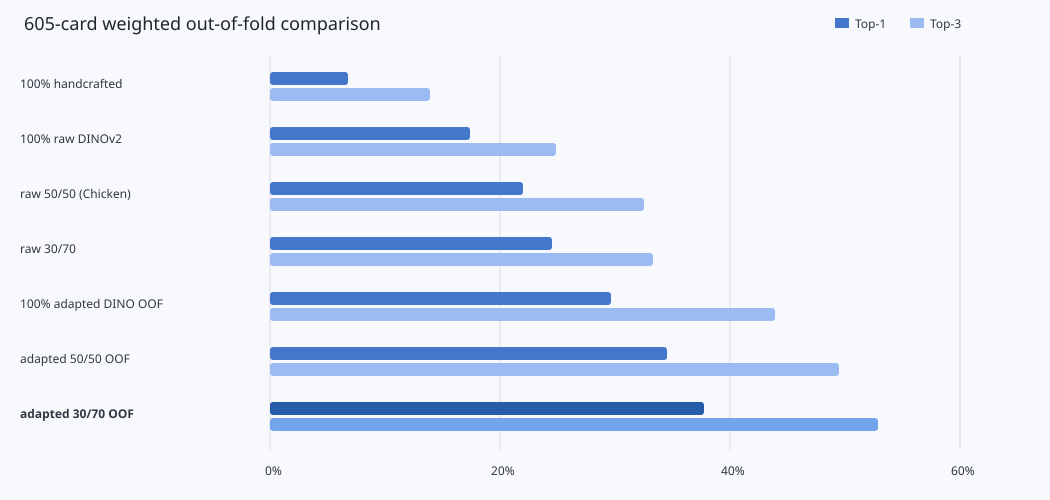

In [9]:
def metric_svg(methods):
    width, height = 1050, 500
    left, scale = 270, 1150
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}">',
        '<rect width="100%" height="100%" fill="#f8f9fc"/>',
        '<text x="24" y="30" font-family="sans-serif" font-size="18">Weighted OOF comparison</text>',
    ]
    for index, (name, (top1, top3)) in enumerate(methods.items()):
        y = 72 + index * 55
        parts += [
            f'<text x="20" y="{y + 13}" font-family="sans-serif" font-size="12">{name}</text>',
            f'<rect x="{left}" y="{y}" width="{top1 * scale:.1f}" height="13" rx="3" fill="#4477cc"/>',
            f'<rect x="{left}" y="{y + 16}" width="{top3 * scale:.1f}" height="13" rx="3" fill="#9abcf2"/>',
        ]
    parts.append("</svg>")
    return "".join(parts)

display(HTML(metric_svg(ALL_METHODS_RECORDED)))


## 8. 配对条件概率

Top-1 只告诉我们整体命中率，不能直接回答“两个模型到底在哪些样本上互相救回来”。因此本实验还对同一张草图的鸡煲预测与新模型折外预测做四格配对。

- `P(鸡煲错 | 新模型对)`：在新模型猜对的样本里，有多少是鸡煲原来猜错、确实被新模型救回的；
- `P(新模型错 | 鸡煲对)`：在鸡煲猜对的样本里，有多少反而被新模型弄错；
- Bootstrap 以整张卡牌为抽样单位，保留同一张卡四个草图之间的相关性。

In [10]:
report = json.loads(REPORT_PATH.read_text(encoding="utf-8"))
paired = report["paired_top1"]
raw = paired["raw_counts"]
weighted = paired["weighted_counts"]
probability = paired["weighted_probabilities"]
interval = paired["clustered_card_bootstrap_95pct"]

labels_cn = {
    "both_correct": "两者都对",
    "new_only_correct": "仅新模型对",
    "chicken_only_correct": "仅鸡煲对",
    "both_wrong": "两者都错",
}
for key, label in labels_cn.items():
    print(f"{label}: {raw[key]}（加权 {weighted[key]:.3f}）")

p1 = probability["p_chicken_wrong_given_new_correct"]
p2 = probability["p_new_wrong_given_chicken_correct"]
ci1 = interval["p_chicken_wrong_given_new_correct"]
ci2 = interval["p_new_wrong_given_chicken_correct"]
print(f"P(鸡煲错 | 新模型对) = {p1:.2%}  [card bootstrap 95%: {ci1[0]:.2%}–{ci1[1]:.2%}]")
print(f"P(新模型错 | 鸡煲对) = {p2:.2%}  [card bootstrap 95%: {ci2[0]:.2%}–{ci2[1]:.2%}]")
print(
    "P(新模型胜出 | 两者结果不一致) = "
    f"{probability['p_new_wins_given_disagreement']:.2%}"
)
print(f"McNemar exact two-sided p = {paired['mcnemar_exact_two_sided_p']:.6g}")


两者都对: 380（加权 107.667）
仅新模型对: 427（加权 120.500）
仅鸡煲对: 84（加权 25.333）
两者都错: 1529（加权 351.500）
P(鸡煲错 | 新模型对) = 52.81%  [card bootstrap 95%: 47.99%–57.67%]
P(新模型错 | 鸡煲对) = 19.05%  [card bootstrap 95%: 14.47%–24.13%]
P(新模型胜出 | 两者结果不一致) = 82.63%
McNemar exact two-sided p = 2.61495e-56


## 9. 分数据来源结果

| 样本类型 | 样本数 | 鸡煲 Top-1 | 新模型 Top-1 |
|---|---:|---:|---:|
| Codex | 605 | 27.60% | 46.45% |
| Stroke2Sketch（合并） | 1,815 | 16.36% | 28.98% |

新模型在两个数据来源上都取得提升。这里仍然是模型生成草图域，不能当作真实玩家总体准确率。

## 10. 最终全量训练与 ONNX 导出

五折只用于无泄漏评估和选择训练轮数。部署模型最后会用全部 2,420 张草图重新训练，并导出动态 batch 的 ONNX：

- 输入：`embedding [batch, 384]`，float32；
- 输出：`adapted_embedding [batch, 384]`，float32；
- opset 18；
- PyTorch 与 ONNX Runtime 逐元素误差约 `6.33e-8`。

In [11]:
import onnxruntime as ort

onnx_path = TRAINING_ROOT / "sketch_adapter_weighted_v2.onnx"
sha256 = hashlib.sha256(onnx_path.read_bytes()).hexdigest()
session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
input_info = session.get_inputs()[0]
output_info = session.get_outputs()[0]
test_output = session.run(
    [output_info.name],
    {input_info.name: np.zeros((2, 384), dtype=np.float32)},
)[0]

assert test_output.shape == (2, 384)
assert np.isfinite(test_output).all()
print("sha256:", sha256)
print("input:", input_info.name, input_info.shape, input_info.type)
print("output:", output_info.name, output_info.shape, output_info.type)
print("runtime test:", test_output.shape, f"finite={np.isfinite(test_output).all()}")


sha256: 071393fde01b68cf47f196f1e900aad50afa5e993f2dd25d1ebb8b106b086be7
input: embedding ['batch', 384] tensor(float)
output: adapted_embedding ['batch', 384] tensor(float)
runtime test: (2, 384) finite=True
